In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [5]:
sns.set_style("whitegrid")
palette =sns.color_palette("crest", n_colors=3)

# Loading Models & Results

lr_model = joblib.load('../models/linear_regression_model.pkl')
ridge_model = joblib.load('../models/ridge_regression_model.pkl')
lasso_model = joblib.load('../models/lasso_regression_model.pkl')
scalar = joblib.load('../models/feature_scaler.pkl')
results = joblib.load('../models/model_results_summary.pkl')


X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']
y_train_pred_lr = results['y_train_pred_linear']
y_test_pred_lr = results['y_test_pred_linear']
y_train_pred_ridge = results['y_train_pred_ridge']
y_test_pred_ridge = results['y_test_pred_ridge']
y_train_pred_lasso = results['y_train_pred_lasso']
y_test_pred_lasso = results['y_test_pred_lasso']
features = results['features']
comparison = results['models_comparison']


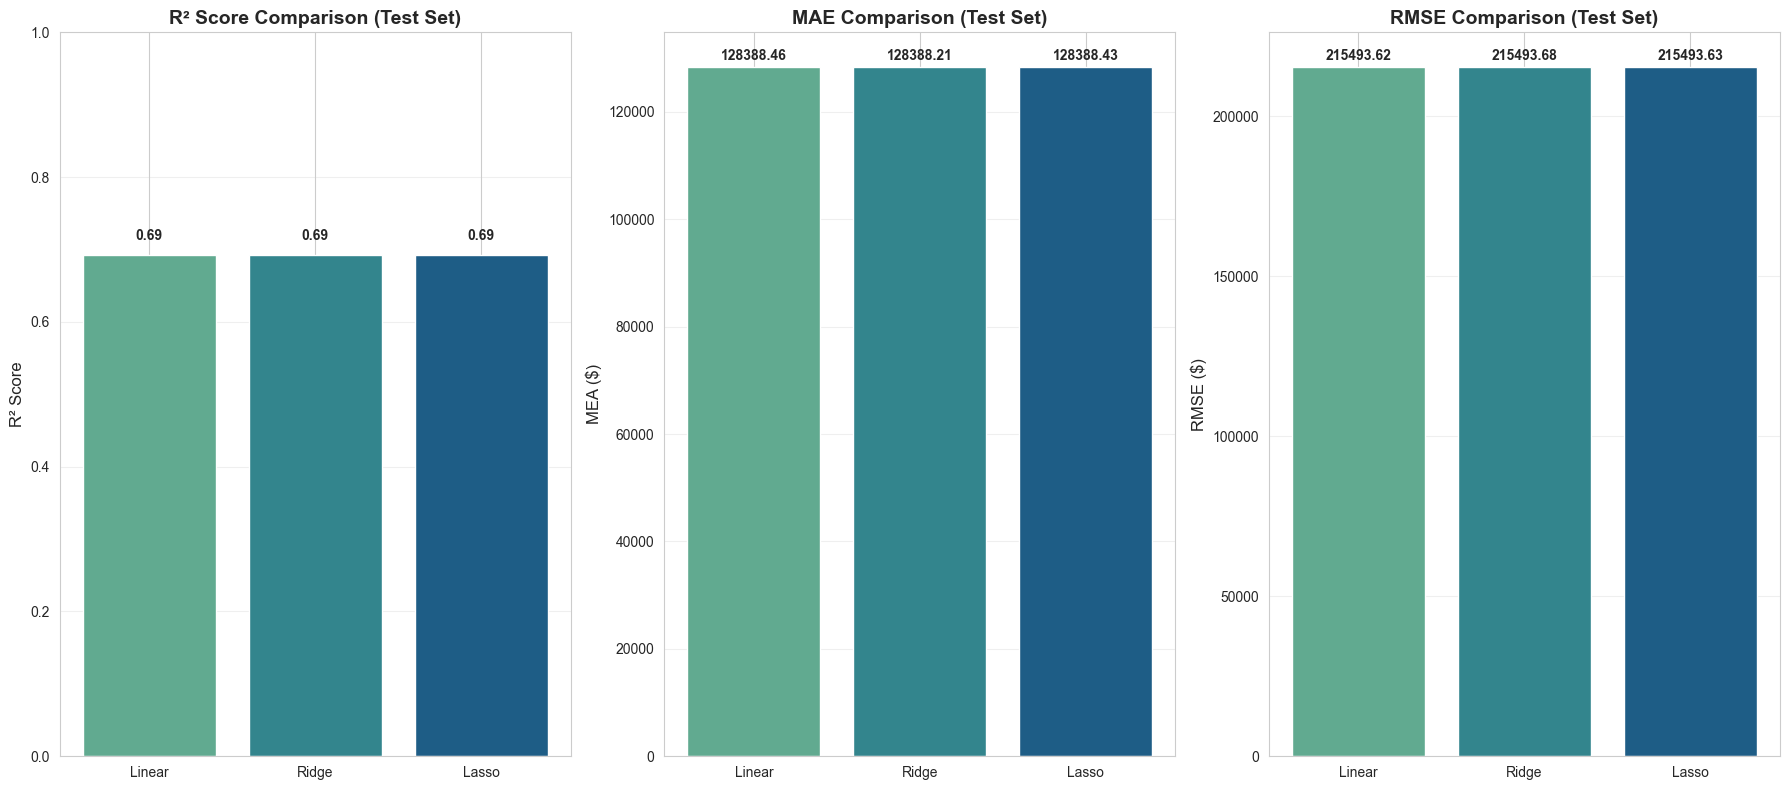

In [14]:
# Model Performance Comparison Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

models = ['Linear', 'Ridge', 'Lasso']
test_r2 = comparison['R² Test'].values
test_mae = comparison['MAE Test'].values
test_rmse = comparison['RMSE Test'].values


# R² Comparison

axes[0].bar(models, test_r2, color=palette)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(True,alpha=0.3, axis='y')
for i, v in enumerate(test_r2):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

# MAE Comparison
axes[1].bar(models, test_mae, color=palette)
axes[1].set_ylabel('MEA ($)', fontsize=12)
axes[1].set_title('MAE Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[1].grid(True,alpha=0.3, axis='y')
for i, v in enumerate(test_mae):
    axes[1].text(i, v + 0.01 * max(test_mae), f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

# RMSE Comparison
axes[2].bar(models, test_rmse, color=palette)
axes[2].set_ylabel('RMSE ($)', fontsize=12)
axes[2].set_title('RMSE Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[2].grid(True,alpha=0.3, axis='y')
for i, v in enumerate(test_rmse):
    axes[2].text(i, v + 0.01 * max(test_rmse), f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()